In [1]:
import torch
import torchvision
from torchvision.transforms import v2,InterpolationMode
from torchvision import datasets
from torch.utils.data import DataLoader,Subset,Dataset
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import torchvision.transforms.functional as TF
from tqdm import tqdm
from torchvision.io import read_image,write_jpeg
from torchvision.transforms.functional import crop,resize
from torchvision.models.detection import ssdlite320_mobilenet_v3_large,SSDLite320_MobileNet_V3_Large_Weights
import os
from torchvision.models.detection import keypointrcnn_resnet50_fpn, KeypointRCNN_ResNet50_FPN_Weights
from torchvision.utils import draw_keypoints
import torch.nn as nn
import torch.nn.functional as F

In [2]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            31Gi       1.3Gi        26Gi       1.0Mi       3.7Gi        29Gi
Swap:             0B          0B          0B


Config

In [4]:
class Config:
    train_ratio = 0.8
    lr = 1e-4
    epochs = 30
    batch_size = 16
cf = Config()

Pipeline data augmentation

In [5]:
train_aug_pipeline = v2.Compose([
    #v2.RandomApply([
        #v2.RandomAffine(
            #degrees = 0,
            #scale = [1.0,1.1],
            #translate = 0,
            #interpolation = InterpolationMode.BILINEAR,
            #fill = 128
        #)
    #], p =0.5),
    v2.RandomApply([
        v2.ColorJitter(brightness = 0.2,contrast = 0.2,saturation = 0.2,hue = 0.1)
    ],p =0.5),
    v2.RandomGrayscale(p = 0.1),
    #v2.RandomApply([
        #v2.GaussianBlur(kernel_size = 5,sigma = (0.1,2.0))
    #], p = 0.3),
    v2.RandomAdjustSharpness(sharpness_factor = 2,p = 0.5)
])

PreProcessing

In [6]:
import os
import cv2
cpu = os.cpu_count()
class LoadDataset(Dataset):
    def __init__(self,img_path,labels,skeletons,transforms = None):
        self.img_path = img_path
        self.labels = labels
        self.transforms = transforms
        self.skeletons = skeletons
    def __len__(self):
        return len(self.img_path)
    def __getitem__(self,idx):
        img_path = self.img_path[idx]
        label = self.labels[idx]
        img = cv2.imread(img_path)
        img = cv2.resize(img,(256,192))
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        img = torch.from_numpy(img.transpose((2,0,1))).contiguous()
        if self.transforms is not None:
            img = self.transforms(img)
        skeleton = self.skeletons[idx]
        ske_tensor = torch.tensor(skeleton,dtype = torch.float32).view(17,3)
        ske_tensor[:,0] /= 256.0
        ske_tensor[:,1] /= 192.0
        return img,label,ske_tensor

In [7]:
from sklearn.preprocessing import LabelEncoder
train_transform = v2.Compose([
    train_aug_pipeline,
    v2.ToImage(),
    v2.ToDtype(torch.float32,scale = True),
    v2.Normalize(mean = [0.485, 0.456, 0.406],std = [0.229, 0.224, 0.225]),
    #v2.RandomErasing(p = 0.3,scale = (0.02,0.1),ratio = (0.5,2.0))
])
val_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32,scale = True),
    v2.Normalize(mean = [0.485, 0.456, 0.406],std = [0.229, 0.224, 0.225])
])
train_dir = "/kaggle/input/competitions/state-farm-distracted-driver-detection/imgs/train"
csv_path = "/kaggle/input/datasets/duanluuvan/coordinate-skeleton/coordinate.csv"
df = pd.read_csv(csv_path)
driver = df.subject.unique()
df['full_path'] = train_dir +"/" + df['classname'].astype(str) + "/" + df['img']
encoder = LabelEncoder()
df['label_encoder'] = encoder.fit_transform(df.classname)
train_driver,val_driver = train_test_split(driver,train_size = 21,random_state = 42)
train = df[df.subject.isin(train_driver)]
val = df[df.subject.isin(val_driver)]
train_path =  train.full_path.tolist()
train_label = train.label_encoder.tolist()
train_skeleton = train.iloc[:,1:-4].values.astype(np.float32)
train_subject = train.subject.tolist()
val_path = val.full_path.tolist()
val_label = val.label_encoder.tolist()
val_skeleton = val.iloc[:,1:-4].values.astype(np.float32)
train_loader = LoadDataset(train_path,train_label,train_skeleton,train_transform)
val_loader = LoadDataset(val_path,val_label,val_skeleton,val_transform)
train_ds = DataLoader(train_loader,batch_size = 16,shuffle = True,pin_memory = True,
                     num_workers = cpu ,prefetch_factor = 2,persistent_workers = True)
val_ds = DataLoader(val_loader,shuffle = False,batch_size = cf.batch_size,pin_memory = True,
                     num_workers = cpu ,prefetch_factor = 2,persistent_workers = True)

Visulize Image

Seed set to 42


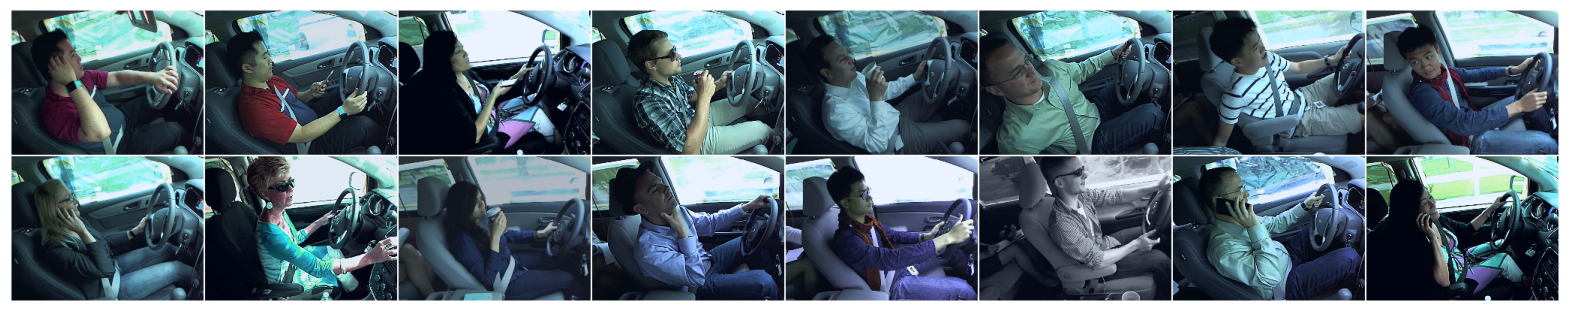

In [8]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import numpy as np
import pytorch_lightning as pl
pl.seed_everything(42)
images,labels,skeletons = next(iter(train_ds))
img_grid = vutils.make_grid(images,nrow = 8,padding = 2,pad_value = 1,normalize = True)
img_np = img_grid.permute(1,2,0).cpu().numpy()
plt.figure(figsize = (20,10))
plt.imshow(img_np)
plt.axis("off")
plt.show()

Callback

In [10]:
from pytorch_lightning.callbacks import LearningRateMonitor,EarlyStopping,ModelCheckpoint
from pytorch_lightning.callbacks import StochasticWeightAveraging,WeightAveraging
from pytorch_lightning.loggers import TensorBoardLogger
from torch.optim.swa_utils import get_ema_avg_fn
class MyEMA(WeightAveraging):
    def should_update(self,step_idx = None,epoch_idx = None):
        return (step_idx is not None) and (step_idx >= 1737)
def training_callback(base_dir = "/kaggle/working/experiments"):
    logger = TensorBoardLogger(save_dir = base_dir,name = "logs")
    checkpoint = ModelCheckpoint(
        dirpath = os.path.join(base_dir,"checkpoints"),
        filename = "best_state_farm_driver_model-{version:.02f}-{epoch:02d}-{val_loss:0.6f}-{val_f1:.06f}",
        monitor = "val_loss",
        mode = "min",
        save_top_k = 1,
        verbose = True
    )
    lr_monitor = LearningRateMonitor(logging_interval = "epoch")
    #early = EarlyStopping(
        #monitor = "val_loss",
        #patience = 11,
        #mode = "min",
       # min_delta = 1e-4,
        #verbose = True
    #)
    swa = StochasticWeightAveraging(swa_epoch_start = 19,swa_lrs = 1e-4)
    return logger,[checkpoint,lr_monitor,swa]

CNN-Transformer hybrid with attention

In [11]:
class AttentionPooling(nn.Module):
    def __init__(self,in_feature,hidden_dim = 384):
        super().__init__()
        self.attention_score = nn.Sequential(
            nn.Linear(in_feature,hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim,1,bias = False)
        )
    def forward(self,x):
        alpha = torch.softmax(self.attention_score(x),dim = 1)
        v = torch.sum(alpha * x,dim = 1)
        return v

In [12]:
class ChannelAttention(nn.Module):
    def __init__(self,in_planes,ratio = 16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1 = nn.Conv2d(in_planes,in_planes // ratio,kernel_size = 1,bias = False)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Conv2d(in_planes // ratio, in_planes,kernel_size = 1,bias = False)
        self.sigmoid = nn.Sigmoid()
        nn.init.zeros_(self.fc2.weight)
    def forward(self,x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out)

In [13]:
class SpatialAttention(nn.Module):
    def __init__(self,kernel_size = 7):
        super().__init__()
        self.conv1 = nn.Conv2d(2,1,kernel_size = kernel_size,padding = 3,bias = False)
        self.sigmoid = nn.Sigmoid()
        nn.init.zeros_(self.conv1.weight)
    def forward(self,x):
        avg_out = torch.mean(x,dim = 1,keepdim = True)
        max_out,_ = torch.max(x,dim = 1,keepdim = True)
        x_cat = torch.cat([avg_out,max_out],dim = 1)
        out = self.conv1(x_cat)
        return self.sigmoid(out)

In [14]:
class CBAM(nn.Module):
    def __init__(self,in_planes ,ratio = 16,kernel_size = 7):
        super().__init__()
        self.ca = ChannelAttention(in_planes,ratio)
        self.sa = SpatialAttention(kernel_size)
    def forward(self,x):
        x = self.ca(x) * x
        x = self.sa(x) * x
        return x

In [48]:
class GaussianDropout(nn.Module):
    def __init__(self,std = 0.05):
        super().__init__()
        self.std = std
    def forward(self,x):
        if self.training:
            noise = torch.randn_like(x) * self.std + 1.0
            x = x * noise
        return x

In [49]:
class AttentionNet(nn.Module):
    def __init__(self,base_model,num_class = 10,embed_dim = 768):
        super().__init__()
        #self.features = base_model.features
        #self.stn = SpatialTransformer()
        self.stem = base_model.features[0]
        #self.cbam_stem = CBAM(in_planes = 96,ratio = 16)
        self.body = nn.Sequential(*list(base_model.features.children())[1:])
        self.cbam_body = CBAM(in_planes = 768,ratio = 16)
        #self.projection = nn.Sequential(
            #nn.Linear(768,512),
            #nn.LayerNorm(512)
        #)
        self.pos_embed = nn.Parameter(torch.zeros(1,48,embed_dim))
        self.noise = GaussianDropout(std = 0.03)
        nn.init.trunc_normal_(self.pos_embed,std = 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model = embed_dim,
            nhead = 8,
            batch_first = True,
            dim_feedforward = 1536,
            dropout = 0.1
        )
        self.self_attention = nn.TransformerEncoder(encoder_layer,num_layers = 1)
        self.attention_pooling = AttentionPooling(in_feature = embed_dim)
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(0.1),
            nn.Linear(embed_dim,num_class)
        )
    def forward(self,x):
        #x,theta = self.stn(x)
        #feature = self.features(x)
        x = self.stem(x)
        x = self.body(x)
        cbam = self.cbam_body(x)
        feature = x + cbam
        feature = self.noise(feature)
        B,C,H,W = feature.shape
        x = feature.view(B,C,H * W).transpose(1,2)
        #x = self.projection(x)
        x = x + self.pos_embed
        x = self.self_attention(x)
        v = self.attention_pooling(x)
        if self.training:
            logit = torch.mean(torch.stack([self.classifier(v) for _ in range(5)]),dim = 0)
            return logit
        else:
            logit = self.classifier(v)
            return logit
        

In [50]:
class MacroF1(nn.Module):
    def __init__(self,num_class = 10,device = 'cuda'):
        super().__init__()
        self.num_class = num_class
        self.device = device
        self.tp = torch.zeros(num_class,device = device)
        self.fn = torch.zeros(num_class,device = device)
        self.fp = torch.zeros(num_class,device = device)
    def update(self,preds,labels):
        pred_one_hot = F.one_hot(preds,num_classes = self.num_class).bool()
        label_one_hot = F.one_hot(labels,num_classes = self.num_class).bool()
        self.tp += torch.sum(pred_one_hot & label_one_hot,dim = 0)
        self.fp += torch.sum(pred_one_hot & ~ label_one_hot,dim = 0)
        self.fn += torch.sum(~pred_one_hot & label_one_hot,dim = 0)
    def compute(self):
        epsilon = 1e-8
        precision = self.tp / (self.tp + self.fp + epsilon)
        recall = self.tp / (self.tp + self.fn + epsilon)
        f1 = 2 * (precision * recall) / (precision + recall + epsilon)
        return f1.mean(),precision.mean(),recall.mean()
    def reset(self):
        self.tp.zero_()
        self.fn.zero_()
        self.fp.zero_()

In [51]:
import pytorch_lightning as pl
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR,LinearLR,SequentialLR
import torch.nn as nn
class LitModel(pl.LightningModule):
    def __init__(self,model):
        super().__init__()
        self.model = model
        self.loss = nn.CrossEntropyLoss()
        self.gpu_scorer = MacroF1(num_class = 10)
        self.cutmix = v2.CutMix(num_classes = 10,alpha = 1.0)
        self.mixup = v2.MixUp(num_classes = 10,alpha  = 0.2)
    def forward(self,images):
        return self.model(images)
    def orthogonal_penalty(self,alpha):
        overlap = torch.bmm(alpha,alpha.transpose(1,2))
        num_heads = alpha.size(1)
        I = torch.eye(num_heads,device = alpha.device).unsqueeze(0)
        outside_diag = overlap * (1-I)
        penalty = torch.norm(outside_diag,p = 'fro',dim = (1,2))
        return penalty.mean()
    def calculator_metrics(self,logits,labels):
        preds = torch.argmax(logits, dim=1)
        acc = (preds == labels).float().mean()
        return acc
    def training_step(self,batch,batch_index):
        images,labels,skeleton = batch
        if torch.rand(1).item() <= 0.5 and (3 <= self.current_epoch):
            images,labels = self.mixup(images,labels)
        #elif torch.rand(1).item() <= 0.6 and (3 <= self.current_epoch):
            #images,labels = self.cutmix(images,labels)
        else:
            labels = F.one_hot(labels,num_classes = 10).float()
        logits = self(images)
        #ortho_loss = self.orthogonal_penalty(alpha)
        #if self.current_epoch <= 5:
            #penalty_weight = 0.0
        #else:
            #penalty_weight = 0.001
        loss = self.loss(logits,labels) 
        #+ penalty_weight * ortho_loss
        acc = self.calculator_metrics(logits,labels.argmax(dim = 1))
        self.log("train_loss",loss,on_step = False,on_epoch = True,prog_bar = True,logger = True)
        self.log("train_acc",acc,on_step = False,on_epoch = True,prog_bar = True)
        #self.log("ortho_loss",ortho_loss,on_step = False,on_epoch = True,prog_bar = True)
        return loss
    def validation_step(self,batch,batch_index):
        images,labels,skeleton = batch
        logits = self(images)
        loss = self.loss(logits,labels)
        acc = self.calculator_metrics(logits, labels)
        preds = torch.argmax(logits,dim = 1)
        self.gpu_scorer.update(preds,labels)
        self.log("val_acc",acc,on_step = False,on_epoch = True,prog_bar = True)
        self.log("val_loss",loss,on_step = False,on_epoch = True,prog_bar = True,logger = True)
        #if batch_index == 0 and self.logger is not None:
            #imgs, _ = self.model.stn(images[:8])
            #grid = torchvision.utils.make_grid(imgs,normalize = True)
            #self.logger.experiment.add_image("STN view",grid,self.current_epoch)
        return loss
    def on_validation_epoch_end(self):
        f1,precision,recall = self.gpu_scorer.compute()
        self.log('val_f1',f1,prog_bar = True)
        self.log('val_pre',precision,prog_bar = True)
        self.log('val_recall',recall,prog_bar = True)
        self.gpu_scorer.reset()
    def configure_optimizers(self):
        params = [
            {'params': self.model.classifier.parameters(),'lr':cf.lr},
            {'params': self.model.self_attention.parameters(),'lr': cf.lr },
            {'params': self.model.attention_pooling.parameters(),'lr':cf.lr },
            #{'params': self.model.projection.parameters(),'lr':cf.lr},
            {'params': [self.model.pos_embed],'lr':cf.lr},
            {'params': self.model.body[6].parameters(),'lr': cf.lr * 1e-1},
            {'params': self.model.body[5].parameters(),'lr': cf.lr * 1e-1},
            {'params': self.model.body[4].parameters(),'lr': cf.lr * 1e-2},
            {'params': self.model.body[3].parameters(),'lr': cf.lr * 1e-2},
            {'params': self.model.body[2].parameters(),'lr': cf.lr * 1e-3},
            {'params': self.model.body[1].parameters(),'lr': cf.lr * 1e-3},
            {'params': self.model.body[0].parameters(),'lr': cf.lr * 1e-4},
            {'params': self.model.stem.parameters(),'lr': cf.lr * 1e-4},
            #{'params': self.model.stn.parameters(),'lr': cf.lr},
            #{'params': self.model.cbam_stem.parameters(),'lr':cf.lr},
            {'params': self.model.cbam_body.parameters(),'lr':cf.lr}
        ]
        optimizer = AdamW(params,lr = 3e-4,weight_decay = 5e-2)
        total_step = self.trainer.estimated_stepping_batches
        step_each_epoch = total_step // 30
        linear = LinearLR(optimizer,
                         start_factor = 0.01,
                         end_factor = 1,
                         total_iters = step_each_epoch * 3)
        cosine = CosineAnnealingLR(
            optimizer,
            T_max = total_step - (3 * step_each_epoch),
            eta_min = 1e-9
        )
        scheduler = SequentialLR(
            optimizer,
            schedulers = [linear,cosine],
            milestones = [step_each_epoch * 3]
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step"
            }
        }

In [52]:
from torchvision.models import convnext_tiny,ConvNeXt_Tiny_Weights
convnext = convnext_tiny(weights = ConvNeXt_Tiny_Weights.DEFAULT
                         ,stochastic_depth_prob = 0
                        )

In [ ]:
print(convnext)

In [40]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
effnet = efficientnet_b0(
    weights = EfficientNet_B0_Weights.DEFAULT,
    stochastic_depth_prob = 0.0
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 130MB/s] 


In [ ]:
print(effnet)

In [53]:
model = AttentionNet(base_model = convnext)

In [54]:
with torch.no_grad():
    model.classifier[2].weight.data *= 1e-3
    if model.classifier[2].bias is not None:
        model.classifier[2].bias.data.zero_()

In [55]:
logger,callback = training_callback()
lit_model = LitModel(model)

In [56]:
trainer = pl.Trainer(
    max_epochs = cf.epochs,
    accelerator = "gpu",
    devices = 1,
    precision = "16-mixed",
    benchmark = True,
    callbacks = callback,
    logger = logger,
    log_every_n_steps = 10
)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [57]:
trainer.fit(model = lit_model,train_dataloaders = train_ds,val_dataloaders = val_ds)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model      │ AttentionNet     │ 33.0 M │ train │     0 │
│ 1 │ loss       │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ gpu_scorer │ MacroF1          │      0 │ train │     0 │
│ 3 │ cutmix     │ CutMix           │      0 │ train │     0 │
│ 4 │ mixup      │ MixUp            │      0 │ train │     0 │
└───┴────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 33.0 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.0 M                                                                                               
Total estimated model params size (MB): 131                                                                        
Modules in train mode: 236                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Epoch 0, global step 1158: 'val_loss' reached 0.68013 (best 0.68013), saving model to '/kaggle/working/experiments/checkpoints/best_state_farm_driver_model-version=0.00-epoch=00-val_loss=0.680126-val_f1=0.748656.ckpt' as top 1
Epoch 1, global step 2316: 'val_loss' reached 0.63952 (best 0.63952), saving model to '/kaggle/working/experiments/checkpoints/best_state_farm_driver_model-version=0.00-epoch=01-val_loss=0.639519-val_f1=0.806938.ckpt' as top 1
Epoch 2, global step 3474: 'val_loss' reached 0.50108 (best 0.50108), saving model to '/kaggle/working/experiments/checkpoints/best_state_farm_driver_model-version=0.00-epoch=02-val_loss=0.501077-val_f1=0.860755.ckpt' as top 1
Epoch 3, global step 4632: 'val_loss' reached 0.37990 (best 0.37990), saving model to '/kaggle/working/experiments/checkpoints/best_state_farm_driver_model-version=0.00-epoch=03-val_loss=0.379900-val_f1=0.873342.ckpt' as top 1
Epoch 4, global step 5790: 'val_loss' reached 0.36675 (best 0.36675), saving model to '/kagg

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/stochastic_weight_avg.py:232: SWA is currently 
only supported every epoch. Found LRSchedulerConfig(scheduler=<torch.optim.lr_scheduler.SequentialLR object at 
0x7d7c35d3a660>, name=None, interval='step', frequency=1, reduce_on_plateau=False, monitor=None, strict=True)

Swapping scheduler `SequentialLR` for `SWALR`
Epoch 18, global step 22002: 'val_loss' reached 0.23354 (best 0.23354), saving model to '/kaggle/working/experiments/checkpoints/best_state_farm_driver_model-version=0.00-epoch=18-val_loss=0.233538-val_f1=0.928849.ckpt' as top 1
Epoch 19, global step 23160: 'val_loss' was not in top 1
Epoch 20, global step 24318: 'val_loss' was not in top 1
Epoch 21, global step 25476: 'val_loss' was not in top 1
Epoch 22, global step 26634: 'val_loss' was not in top 1
Epoch 23, global step 27792: 'val_loss' reached 0.22111 (best 0.22111), saving model to '/kaggle/working/experiments/checkpoints/best_state_farm_driver_model-version=0.00-epoch=23-val_loss=0.221112-val_f1=0.924680.ckpt' as top 1
Epoch 24, global step 28950: 'val_loss' was not in top 1
Epoch 25, global step 30108: 'val_loss' was not in top 1
Epoch 26, global step 31266: 'val_loss' reached 0.18087 (best 0.18087), saving model to '/kaggle/working/experiments/checkpoints/best_state_farm_driver_mo

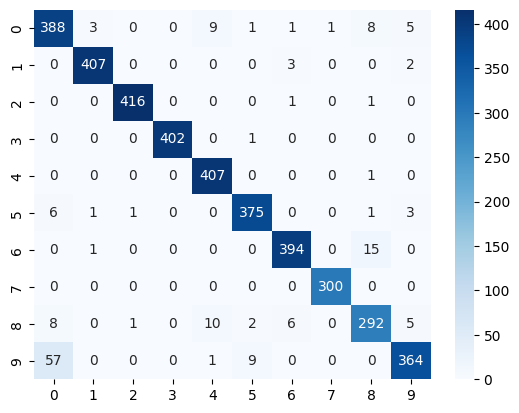

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
best_path = trainer.checkpoint_callback.best_model_path
lit_model = LitModel.load_from_checkpoint(best_path,model = model,weights_only = False)
lit_model.eval()
lit_model.cuda()
preds,labels = [],[]
with torch.no_grad():
    for img,label,_ in val_ds:
        img = img.cuda()
        preds.extend(lit_model(img).argmax(dim = 1).cpu().numpy())
        label = label.argmax(dim = 1) if label.dim() > 1 else label
        labels.extend(label.cpu().numpy())

cm = confusion_matrix(labels,preds)
sns.heatmap(cm,annot = True,fmt = 'd',cmap = "Blues")
plt.show()

Phase 2

In [60]:
import os
import cv2
cpu = os.cpu_count()
class LoadDataset(Dataset):
    def __init__(self,img_path,labels,skeletons,transforms = None):
        self.img_path = img_path
        self.labels = labels
        self.transforms = transforms
        self.skeletons = skeletons
    def __len__(self):
        return len(self.img_path)
    def __getitem__(self,idx):
        img_path = self.img_path[idx]
        label = self.labels[idx]
        img = cv2.imread(img_path)
        img = cv2.resize(img,(384,288))
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        img = torch.from_numpy(img.transpose((2,0,1))).contiguous()
        if self.transforms is not None:
            img = self.transforms(img)
        skeleton = self.skeletons[idx]
        ske_tensor = torch.tensor(skeleton,dtype = torch.float32).view(17,3)
        ske_tensor[:,0] /= 384.0
        ske_tensor[:,1] /= 288.0
        return img,label,ske_tensor

In [61]:
from sklearn.preprocessing import LabelEncoder
train_transform = v2.Compose([
    train_aug_pipeline,
    v2.ToImage(),
    v2.ToDtype(torch.float32,scale = True),
    v2.Normalize(mean = [0.485, 0.456, 0.406],std = [0.229, 0.224, 0.225]),
    #v2.RandomErasing(p = 0.3,scale = (0.02,0.1),ratio = (0.5,2.0))
])
val_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32,scale = True),
    v2.Normalize(mean = [0.485, 0.456, 0.406],std = [0.229, 0.224, 0.225])
])
train_dir = "/kaggle/input/competitions/state-farm-distracted-driver-detection/imgs/train"
csv_path = "/kaggle/input/datasets/duanluuvan/coordinate-skeleton/coordinate.csv"
df = pd.read_csv(csv_path)
driver = df.subject.unique()
df['full_path'] = train_dir +"/" + df['classname'].astype(str) + "/" + df['img']
encoder = LabelEncoder()
df['label_encoder'] = encoder.fit_transform(df.classname)
train_driver,val_driver = train_test_split(driver,train_size = 21,random_state = 42)
train = df[df.subject.isin(train_driver)]
val = df[df.subject.isin(val_driver)]
train_path =  train.full_path.tolist()
train_label = train.label_encoder.tolist()
train_skeleton = train.iloc[:,1:-4].values.astype(np.float32)
train_subject = train.subject.tolist()
#train_sampler = DriverSampler(subjects = train_subject,batch_size =16)
#train_skeleton_aug = augmentation_skeleton(train_skeleton)
val_path = val.full_path.tolist()
val_label = val.label_encoder.tolist()
val_skeleton = val.iloc[:,1:-4].values.astype(np.float32)
#val_skeleton_aug = augmentation_skeleton(val_skeleton)
train_loader = LoadDataset(train_path,train_label,train_skeleton,train_transform)
val_loader = LoadDataset(val_path,val_label,val_skeleton,val_transform)
train_ds = DataLoader(train_loader,batch_size = 16,shuffle = True,pin_memory = True,
                     num_workers = cpu ,prefetch_factor = 2,persistent_workers = True)
val_ds = DataLoader(val_loader,shuffle = False,batch_size = cf.batch_size,pin_memory = True,
                     num_workers = cpu ,prefetch_factor = 2,persistent_workers = True)

Seed set to 42


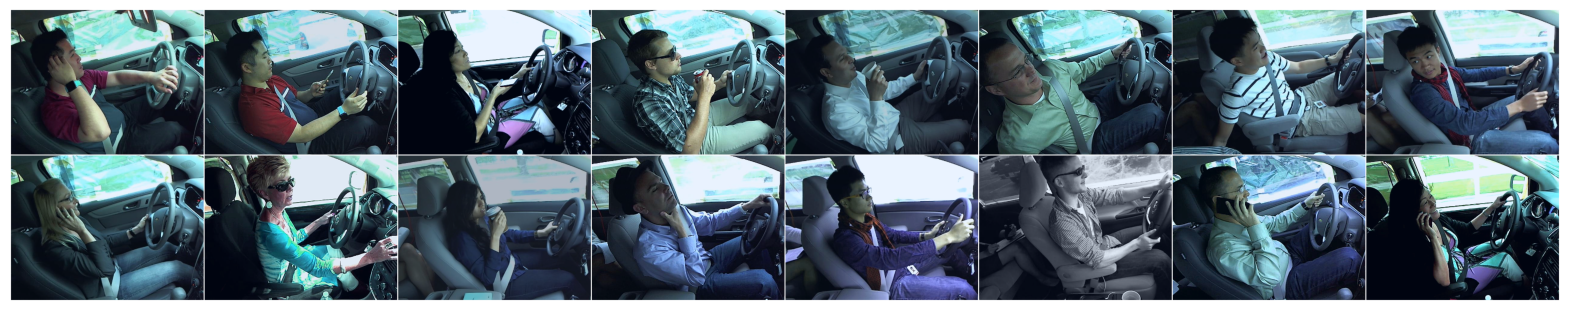

In [62]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import numpy as np
import pytorch_lightning as pl
pl.seed_everything(42)
images,labels,skeletons = next(iter(train_ds))
img_grid = vutils.make_grid(images,nrow = 8,padding = 2,pad_value = 1,normalize = True)
img_np = img_grid.permute(1,2,0).cpu().numpy()
plt.figure(figsize = (20,10))
plt.imshow(img_np)
plt.axis("off")
plt.show()

In [ ]:
from pytorch_lightning.callbacks import LearningRateMonitor,EarlyStopping,ModelCheckpoint
from pytorch_lightning.callbacks import StochasticWeightAveraging,WeightAveraging
from pytorch_lightning.loggers import TensorBoardLogger
from torch.optim.swa_utils import get_ema_avg_fn
class MyEMA(WeightAveraging):
    def should_update(self,step_idx = None,epoch_idx = None):
        return (step_idx is not None) and (step_idx >= 1737)
def training_callback(base_dir = "/kaggle/working/experiments"):
    logger = TensorBoardLogger(save_dir = base_dir,name = "logs")
    checkpoint = ModelCheckpoint(
        dirpath = os.path.join(base_dir,"checkpoints"),
        filename = "best_state_farm_driver_model-{version:.02f}-{epoch:02d}-{val_loss:0.6f}-{val_f1:.06f}",
        monitor = "val_loss",
        mode = "min",
        save_top_k = 1,
        verbose = True
    )
    lr_monitor = LearningRateMonitor(logging_interval = "epoch")
    #early = EarlyStopping(
        #monitor = "val_loss",
        #patience = 11,
        #mode = "min",
       # min_delta = 1e-4,
        #verbose = True
    #)
    swa = StochasticWeightAveraging(swa_epoch_start = 12,swa_lrs = 3e-6)
    return logger,[checkpoint,lr_monitor,swa]

In [64]:
class AttentionNet(nn.Module):
    def __init__(self,base_model,num_class = 10,embed_dim = 768):
        super().__init__()
        #self.features = base_model.features
        #self.stn = SpatialTransformer()
        self.stem = base_model.features[0]
        #self.cbam_stem = CBAM(in_planes = 96,ratio = 16)
        self.body = nn.Sequential(*list(base_model.features.children())[1:])
        self.cbam_body = CBAM(in_planes = 768,ratio = 16)
        #self.projection = nn.Sequential(
            #nn.Linear(768,512),
            #nn.LayerNorm(512)
        #)
        self.pos_embed = nn.Parameter(torch.zeros(1,108,embed_dim))
        self.noise = GaussianDropout(std = 0.03)
        nn.init.trunc_normal_(self.pos_embed,std = 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model = embed_dim,
            nhead = 8,
            batch_first = True,
            dim_feedforward = 1536,
            dropout = 0.1
        )
        self.self_attention = nn.TransformerEncoder(encoder_layer,num_layers = 1)
        self.attention_pooling = AttentionPooling(in_feature = embed_dim)
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(0.1),
            nn.Linear(embed_dim,num_class)
        )
    def forward(self,x):
        #x,theta = self.stn(x)
        #feature = self.features(x)
        x = self.stem(x)
        x = self.body(x)
        cbam = self.cbam_body(x)
        feature = x + cbam
        feature = self.noise(feature)
        B,C,H,W = feature.shape
        x = feature.view(B,C,H * W).transpose(1,2)
        #x = self.projection(x)
        x = x + self.pos_embed
        x = self.self_attention(x)
        v = self.attention_pooling(x)
        if self.training:
            logit = torch.mean(torch.stack([self.classifier(v) for _ in range(5)]),dim = 0)
            return logit
        else:
            logit = self.classifier(v)
            return logit
        

In [ ]:
import pytorch_lightning as pl
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR,LinearLR,SequentialLR
import torch.nn as nn
class LitModel(pl.LightningModule):
    def __init__(self,model):
        super().__init__()
        self.model = model
        self.loss = nn.CrossEntropyLoss()
        self.gpu_scorer = MacroF1(num_class = 10)
        self.cutmix = v2.CutMix(num_classes = 10,alpha = 1.0)
        self.mixup = v2.MixUp(num_classes = 10,alpha  = 0.2)
    def forward(self,images):
        return self.model(images)
    def orthogonal_penalty(self,alpha):
        overlap = torch.bmm(alpha,alpha.transpose(1,2))
        num_heads = alpha.size(1)
        I = torch.eye(num_heads,device = alpha.device).unsqueeze(0)
        outside_diag = overlap * (1-I)
        penalty = torch.norm(outside_diag,p = 'fro',dim = (1,2))
        return penalty.mean()
    def calculator_metrics(self,logits,labels):
        preds = torch.argmax(logits, dim=1)
        acc = (preds == labels).float().mean()
        return acc
    def training_step(self,batch,batch_index):
        images,labels,skeleton = batch
        if torch.rand(1).item() <= 0.5 and (3 <= self.current_epoch <= 12):
            images,labels = self.mixup(images,labels)
        else:
            labels = F.one_hot(labels,num_classes = 10).float()
        logits = self(images)
        loss = self.loss(logits,labels) 
        #+ penalty_weight * ortho_loss
        acc = self.calculator_metrics(logits,labels.argmax(dim = 1))
        self.log("train_loss",loss,on_step = False,on_epoch = True,prog_bar = True,logger = True)
        self.log("train_acc",acc,on_step = False,on_epoch = True,prog_bar = True)
        return loss
    def validation_step(self,batch,batch_index):
        images,labels,skeleton = batch
        logits = self(images)
        loss = self.loss(logits,labels)
        acc = self.calculator_metrics(logits, labels)
        preds = torch.argmax(logits,dim = 1)
        self.gpu_scorer.update(preds,labels)
        self.log("val_acc",acc,on_step = False,on_epoch = True,prog_bar = True)
        self.log("val_loss",loss,on_step = False,on_epoch = True,prog_bar = True,logger = True)
        return loss
    def on_validation_epoch_end(self):
        f1,precision,recall = self.gpu_scorer.compute()
        self.log('val_f1',f1,prog_bar = True)
        self.log('val_pre',precision,prog_bar = True)
        self.log('val_recall',recall,prog_bar = True)
        self.gpu_scorer.reset()
    def configure_optimizers(self):
        params = [
            {'params': self.model.classifier.parameters(),'lr':cf.lr},
            {'params': self.model.self_attention.parameters(),'lr': cf.lr },
            {'params': self.model.attention_pooling.parameters(),'lr':cf.lr },
            #{'params': self.model.projection.parameters(),'lr':cf.lr},
            {'params': [self.model.pos_embed],'lr':cf.lr},
            {'params': self.model.body[6].parameters(),'lr': cf.lr * 1e-1},
            {'params': self.model.body[5].parameters(),'lr': cf.lr * 1e-1},
            {'params': self.model.body[4].parameters(),'lr': cf.lr * 1e-2},
            {'params': self.model.body[3].parameters(),'lr': cf.lr * 1e-2},
            {'params': self.model.body[2].parameters(),'lr': cf.lr * 1e-3},
            {'params': self.model.body[1].parameters(),'lr': cf.lr * 1e-3},
            {'params': self.model.body[0].parameters(),'lr': cf.lr * 1e-4},
            {'params': self.model.stem.parameters(),'lr': cf.lr * 1e-4},
            #{'params': self.model.stn.parameters(),'lr': cf.lr},
            #{'params': self.model.cbam_stem.parameters(),'lr':cf.lr},
            {'params': self.model.cbam_body.parameters(),'lr':cf.lr}
        ]
        optimizer = AdamW(params,lr = 1e-5,weight_decay = 5e-2)
        total_step = self.trainer.estimated_stepping_batches
        step_each_epoch = total_step // 15
        linear = LinearLR(optimizer,
                         start_factor = 0.01,
                         end_factor = 1,
                         total_iters = step_each_epoch * 1)
        cosine = CosineAnnealingLR(
            optimizer,
            T_max = total_step - (1 * step_each_epoch),
            eta_min = 1e-10
        )
        scheduler = SequentialLR(
            optimizer,
            schedulers = [linear,cosine],
            milestones = [1 * step_each_epoch]
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step"
            }
        }

In [77]:
def load_and_interpolate_weights(lit_model_phase2,best_path):
    checkpoint = torch.load(best_path,weights_only=False)
    state_dict = checkpoint['state_dict']
    old_embed = state_dict["model.pos_embed"]
    old_embed = old_embed.transpose(1,2).view(1,768,6,8)
    new_embed = F.interpolate(
        old_embed,
        size = (9,12),
        mode = 'bicubic',
        align_corners = False
    )
    new_embed = new_embed.flatten(2).transpose(1,2)
    state_dict["model.pos_embed"] = new_embed
    lit_model_phase2.load_state_dict(state_dict)
    return lit_model_phase2

In [78]:
from torchvision.models import convnext_tiny,ConvNeXt_Tiny_Weights
convnext = convnext_tiny(weights = ConvNeXt_Tiny_Weights.DEFAULT
                         ,stochastic_depth_prob = 0
                        )

In [79]:
model2 = AttentionNet(base_model = convnext)

In [80]:
logger,callback = training_callback()
lit_model2 = LitModel(model2)
lit_model2 = load_and_interpolate_weights(lit_model2,best_path)

In [81]:
trainer2 = pl.Trainer(
    max_epochs = 15,
    accelerator = "gpu",
    devices = 1,
    precision = "16-mixed",
    benchmark = True,
    callbacks = callback,
    logger = logger,
    log_every_n_steps = 10
)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [82]:
trainer2.fit(model = lit_model2,train_dataloaders = train_ds,val_dataloaders = val_ds)

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model      │ AttentionNet     │ 33.0 M │ train │     0 │
│ 1 │ loss       │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ gpu_scorer │ MacroF1          │      0 │ train │     0 │
│ 3 │ cutmix     │ CutMix           │      0 │ train │     0 │
│ 4 │ mixup      │ MixUp            │      0 │ train │     0 │
└───┴────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 33.0 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.0 M                                                                                               
Total estimated model params size (MB): 132                                                                        
Modules in train mode: 236                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Epoch 0, global step 1158: 'val_loss' reached 0.17576 (best 0.17576), saving model to '/kaggle/working/experiments/checkpoints/best_state_farm_driver_model-version=0.00-epoch=00-val_loss=0.175756-val_f1=0.955012.ckpt' as top 1
Epoch 1, global step 2316: 'val_loss' was not in top 1
Epoch 2, global step 3474: 'val_loss' was not in top 1
Epoch 3, global step 4632: 'val_loss' reached 0.17526 (best 0.17526), saving model to '/kaggle/working/experiments/checkpoints/best_state_farm_driver_model-version=0.00-epoch=03-val_loss=0.175262-val_f1=0.963479.ckpt' as top 1
Epoch 4, global step 5790: 'val_loss' reached 0.16413 (best 0.16413), saving model to '/kaggle/working/experiments/checkpoints/best_state_farm_driver_model-version=0.00-epoch=04-val_loss=0.164127-val_f1=0.962498.ckpt' as top 1
Epoch 5, global step 6948: 'val_loss' was not in top 1
Epoch 6, global step 8106: 'val_loss' was not in top 1
Epoch 7, global step 9264: 'val_loss' was not in top 1
Epoch 8, global step 10422: 'val_loss' was n

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/stochastic_weight_avg.py:232: SWA is currently 
only supported every epoch. Found LRSchedulerConfig(scheduler=<torch.optim.lr_scheduler.SequentialLR object at 
0x7d7cfc9bd7f0>, name=None, interval='step', frequency=1, reduce_on_plateau=False, monitor=None, strict=True)

Swapping scheduler `SequentialLR` for `SWALR`
Epoch 11, global step 13896: 'val_loss' was not in top 1
Epoch 12, global step 15054: 'val_loss' was not in top 1
Epoch 13, global step 16212: 'val_loss' was not in top 1
Epoch 14, global step 17370: 'val_loss' was not in top 1
`Trainer.fit` stopped: `max_epochs=15` reached.


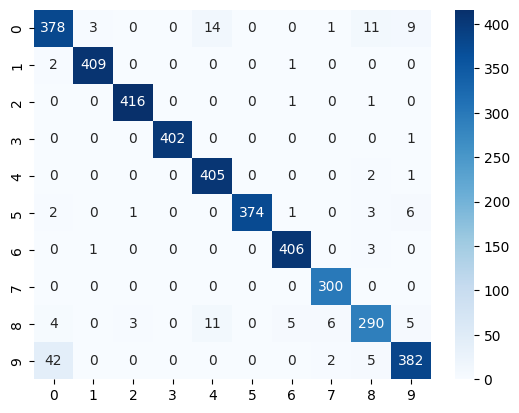

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
best_path = trainer2.checkpoint_callback.best_model_path
lit_model = LitModel.load_from_checkpoint(best_path,model = model2,weights_only = False)
lit_model.eval()
lit_model.cuda()
preds,labels = [],[]
with torch.no_grad():
    for img,label,_ in val_ds:
        img = img.cuda()
        preds.extend(lit_model2(img).argmax(dim = 1).cpu().numpy())
        label = label.argmax(dim = 1) if label.dim() > 1 else label
        labels.extend(label.cpu().numpy())

cm = confusion_matrix(labels,preds)
sns.heatmap(cm,annot = True,fmt = 'd',cmap = "Blues")
plt.show()

In [86]:
import pandas as pd
import torch
import os
from glob import glob
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm

class StateFarmTestDataset(Dataset):
    def __init__(self, test_dir, transform=None):
        self.img_paths = glob(os.path.join(test_dir, '*.jpg'))
        self.transform = transform
    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = read_image(img_path)
        if img.shape[0] == 1:
            img = img.repeat(3, 1, 1)
        if self.transform:
            img = self.transform(img)
        img_name = os.path.basename(img_path)
        return img, img_name
test_transform = v2.Compose([
    v2.Resize((288, 384), antialias=True), 
    v2.ToImage(),
    v2.ToDtype(torch.float32,scale = True)
])
normalize = v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
tta_transforms = v2.Compose([
    v2.RandomApply([
        v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
    ], p=0.8),
    v2.RandomGrayscale(p=0.2),
    v2.RandomAdjustSharpness(sharpness_factor=2, p=0.8)
])
n_tta = 5
test_dir = '/kaggle/input/competitions/state-farm-distracted-driver-detection/imgs/test'
test_dataset = StateFarmTestDataset(test_dir, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)
model.eval() 
model.cuda()
results = []
print("starting predict...")
with torch.no_grad(): 
    for imgs, img_names in tqdm(test_loader):
        imgs = imgs.cuda()
        batch_probs_sum = torch.zeros((imgs.size(0), 10)).cuda()
        logits_orig = model2(normalize(imgs))
        batch_probs_sum += torch.softmax(logits_orig, dim=1)
        for _ in range(n_tta - 1):
            aug_imgs = tta_transforms(imgs) 
            logits_aug = model2(normalize(aug_imgs)) 
            batch_probs_sum += torch.softmax(logits_aug, dim=1)
        final_probs = (batch_probs_sum / n_tta).cpu().numpy()
        for name, prob in zip(img_names, final_probs):
            row = {'img': name}
            for i in range(10):
                row[f'c{i}'] = prob[i]
            results.append(row)
df = pd.DataFrame(results)
cols = ['img'] + [f'c{i}' for i in range(10)]
df = df[cols]
submission_path = '/kaggle/working/submission.csv'
df.to_csv(submission_path, index=False)


starting predict...


100%|██████████| 1246/1246 [1:11:20<00:00,  3.44s/it]
